# Tarea 1 - 2026
## Análisis de Productividad Estudiantil

**Curso:** DAML 

**Datos:** `student_productivity.csv`  
**Fecha de entrega:** 20/04/2026

**Nombre:** Vicente Carrasco Pereira


---
**P1: Cargar la base de datos en el ambiente. Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario. Genere una variable binaria para indicar quienes dieron el test. Justifique su proceso.**}

Durante la fase de carga de datos, se identificaron variables numéricas (float) y categóricas (object). El proceso de limpieza se centró en la estandarización de las variables `academic_level` y `part_time_job` debido a inconsistencias en sus entradas. Por otro lado, se descartó la variable `drug_use` al presentar un 73% de valores faltantes, cifra que compromete su utilidad analítica.

Respecto a `exercise_minutes`, se transformó de tipo object a float tras eliminar el sufijo "min" en sus registros y se cambió a `exercise_hours`. En cuanto a los valores atípicos, se decidió conservar los outliers para prevenir el sesgo de selección, fundamentando esta decisión en la robustez de los modelos de regresión ante valores extremos moderados en muestras de gran tamaño.

Finalmente, se generó la variable binaria `took_test` para identificar a quienes realizaron el examen (basada en el indicador `exam_score` == 1.0 para inasistencias) y se procedió a eliminar las filas con datos nulos restantes para garantizar la integridad del análisis final.

---
**P2: Ejecute un modelo de probabilidad lineal (MCO) que permita explicar la probabilidad de que un alumno rinda el examen, a partir de las informacion disponible. Seleccione las variables dependientes a incluir en el modelo final e interprete su significado.**

 Análisis del modelo

- El modelo explica el 24.7% de la probabilidad de que un alumno rinda el examen. Es un valor sólido para un Modelo de Probabilidad Lineal (MPL) en ciencias sociales/comportamiento.
- Prob (F-statistic) es prácticamente cero, lo que indica que el conjunto de variables seleccionadas explica de manera real y no aleatoria el fenómeno.
- Se mantiene el uso de errores estándar HC3, lo cual es correcto para corregir la heterocedasticidad intrínseca del MPL.
- Se seleccionan las variablas dependientes a incluir a continuación basándose en la significancia.

 Interpretación de los coeficientes

- Productivity Score (0.0057): Es el factor positivo con mayor peso unitario. Por cada punto que aumenta el score de productividad, la probabilidad de rendir el examen aumenta en 0.57 puntos porcentuales. Un incremento de 10 puntos en productividad subiría la probabilidad en un 5.7%.

- Focus Index (0.0038): Un mayor nivel de enfoque favorece la asistencia. Por cada punto adicional en este índice, la probabilidad de rendir aumenta en 0.38 puntos porcentuales.

- Burnout Level (-0.0025): Es el único factor disuasorio. Por cada punto de aumento en el nivel de agotamiento o "burnout", la probabilidad de rendir el examen disminuye en 0.25 puntos porcentuales.

- Academic Level Undergraduate (0.0271): Los estudiantes de grado (undergraduate) tienen una probabilidad 2.71 puntos porcentuales mayor de rendir el examen en comparación con el nivel de referencia (otros niveles académicos), manteniendo el resto de las variables constantes.

- Constante (0.6929): Representa la probabilidad base. Si un estudiante tuviera valores de cero en enfoque, productividad y burnout (y no fuera de grado), su probabilidad de rendir sería del 69.29%.

---
**P3: Ejecute un modelo probit para responder a la pregunta 2. Seleccione las variables dependientes a incluir en el modelo final e interprete su significado.**

Análisis del modelo

- El Pseudo R-squared (0.588) indica un ajuste muy alto.
- El modelo es extremadamente robusto. Todas las variables seleccionadas tienen un P-value de 0.000 (o 0.005 para Undergraduate).
- El modelo advierte que predice perfectamente el 45% de los casos.
- Al igual que en el modelo anterior, se mantienen las mismas variables significativas.

Interpretación de los coeficientes

- Productivity Score (0.0068): Es la variable con mayor impacto. Por cada punto adicional en el score de productividad, la probabilidad de rendir el examen aumenta en 0.68 puntos porcentuales.

- Focus Index (0.0034): Por cada punto extra en el índice de enfoque, la probabilidad de rendir aumenta en 0.34 puntos porcentuales.

- Burnout Level (-0.0024): Por cada punto que aumenta el nivel de agotamiento, la probabilidad de rendir disminuye en 0.24 puntos porcentuales.

- Academic Level Undergraduate (0.0182): Manteniendo constante el nivel de productividad, enfoque y burnout, ser un estudiante de grado (undergraduate) aumenta la probabilidad de rendir en 1.82 puntos porcentuales en comparación con otros niveles académicos.


---
**P4: Ejecute un modelo logit para responder a la pregunta 2. Seleccione las variables dependientes a incluir en el modelo final e interprete su significado.**

Análisis del modelo

- El Pseudo R-squared (0.586) indica un ajuste muy alto y una accuracy del 94.6%
- La significancia global dada por LLR p-value es practicamente cero, lo que confirma que las variables elegidas en conjunto explican el fenómeno de manera muy potente.
- El modelo advierte que predice perfectamente el 25% de los casos.
- Se mantienen las mismas variables.

Interpretación de los coeficientes

- Productivity Score:
    - AME 0.0068: Es la variable con mayor impacto. Por cada punto adicional en el score de productividad, la probabilidad de rendir el examen aumenta en 0.68 puntos porcentuales.
    - OR 1.203: Por cada punto adicional en el score de productividad, las probabilidades de tomar el examen suben un 20.3%.

- Focus Index:
    - AME 0.0034: Por cada punto extra en el índice de enfoque, la probabilidad de rendir aumenta en 0.34 puntos porcentuales.
    - OR 1.098: Un incremento unitario en el índice de enfoque eleva las probabilidades en un 9.8%. Es positivo, aunque su impacto por unidad es menor que el de la productividad.

- Burnout Level:
    - AME -0.0024: Por cada punto que aumenta el nivel de agotamiento, la probabilidad de rendir disminuye en 0.24 puntos porcentuales.
    - OR 0.936: Por cada punto que sube el nivel de burnout, las probabilidades de tomar el examen disminuyen un 6.4%

- Academic Level Undergraduate:
    - AME 0.0182: Manteniendo constante el nivel de productividad, enfoque y burnout, ser un estudiante de grado (undergraduate) aumenta la probabilidad de rendir en 1.82 puntos porcentuales en comparación con otros niveles académicos.
    - OR 1.608: Ser estudiante de pregrado (Undergraduate) aumenta las probabilidades de tomar el examen en un 60.8% en comparación con el grupo de referencia, manteniendo todo lo demás constante. Es el predictor categórico más fuerte.

---
**P5: Comente los resultados obtenidos en 2, 3 y 4. ¿Cuáles y por qué existen las diferencias entre los resultados?. En su opinión, ¿Cuál sería el más adecuado para responder la pregunta de investgación y por qué? ¿Qué variables resultaron ser robustas a la especificación?**

Los resultados muestran una alta consistencia en la dirección y significancia de los efectos entre los tres modelos. En todos los casos, el `focus_index` y el `productivity_score` tienen impactos positivos, mientras que el `burnout_level` afecta de forma negativa. Las diferencias numéricas en los coeficientes surgen porque el MPL asume una relación lineal constante, mientras que Probit y Logit utilizan funciones no lineales (distribuciones Normal y Logística) que ajustan mejor la probabilidad a los límites de 0 y 1. Esto se refleja en la superioridad de los modelos no lineales en términos de Pseudo-R² (0.58 vs 0.24) y Accuracy.

En mi opinión, el modelo Probit es el más adecuado para responder la pregunta de investigación. No solo presenta la mayor precisión predictiva (94.69%), sino que también posee los valores más bajos de AIC (993.96) y BIC (1025.46), lo que estadísticamente indica un mejor equilibrio entre la complejidad del modelo y su capacidad de ajuste. Finalmente, las variables Productivity Score, Focus Index, Bournout Level y Academic Level Undergraduate resultaron ser robustas, ya que mantuvieron su significancia estadística y el sentido de su impacto a través de las distintas especificaciones, demostrando que los hallazgos son sólidos independientemente del método de estimación elegido.

---
**P6: Use un modelo Poisson para explicar la nota del examen, entre aquellos alumnos que lo rindieron. Seleccione las variables dependientes a incluir en el modelo final e interprete su significado** 

Para realizar el modelo se utilizó la variable `exam_score` la cual se aproximó al valor entero `exam_score_int` para poder ajustar el modelo. Las variables incluidas en el modelo final fueron las siguientes

- Productivity Score
    - IRR (1.02): Por cada punto extra de productividad, la nota del examen aumenta un 2%
    - AME (0.4347): En términos absolutos, un aumento de 1 punto en productividad se traduce en un incremento promedio de 0.43 puntos en la nota final.

- Focus Index:
    - IRR (1.01): Cada punto de enfoque aumenta la nota en un 1%.
    - AME (0.2738): Un punto más en el índice de enfoque sube la nota en 0.27 puntos promedio.

- Mental Health Score
    - IRR (1.01): Tiene un impacto porcentual similar al enfoque (aprox. 1%).
    - AME (0.1517): Es el impacto absoluto más bajo de los positivos, sumando 0.15 puntos por cada unidad de mejora en salud mental.

- Burnout Level
    - IRR (0.99): Por cada punto de burnout, la nota del examen cae un 1%.
    - AME (-0.1894): Cada nivel adicional de agotamiento resta, en promedio, casi 0.20 puntos de la nota del examen.

---
**P7: Determine si existe sobre dispersion en la data y posible valor optimo de alpha para un modelo Binomial Negativa.**

Los resultados confirman de manera contundente la existencia de sobredispersión en los datos. Esto se evidencia inicialmente al observar que la varianza (127.35) es significativamente mayor que la media (20.52), con un ratio de 6.205, lo cual rompe el supuesto de equidispersión propio del modelo Poisson. Esta conclusión se ratifica mediante el Test de Cameron & Trivedi, donde el p-valor de 0.0000 permite rechazar la hipótesis nula de equidispersión, validando que el parámetro de dispersión $\alpha$ es significativamente mayor a cero. Asimismo, la dispersión de Pearson de 1.61 refuerza que la variabilidad de los datos excede lo esperado por un modelo de conteo simple.

En cuanto al valor óptimo para un modelo de Binomial Negativa, la estimación arroja un $\alpha$ de 0.0285. Este valor es estadísticamente sólido, ya que su intervalo de confianza al 95% (0.0244, 0.0326) no incluye el cero, confirmando que la estructura de la varianza se ajusta mejor a la forma $Var(Y|X) = \mu + \alpha\mu^2$. Por lo tanto, utilizar este valor de $\alpha$ en una Binomial Negativa permitirá corregir el sesgo en los errores estándar que produciría un modelo Poisson, garantizando inferencias más precisas sobre el puntaje de los exámenes.

<div align="center">

| Criterio | Valor | Conclusión |
|:---|:---:|:---|
| Ratio Var/Media incondicional | >> 1 | Sobredispersión |
| Dispersión de Pearson | >> 1 | Sobredispersión |
| Test Cameron & Trivedi p-value | < 0.05 | Rechazar equidispersión |
| α estimado (NB) | > 0, IC no incluye 0 | Sobredispersión confirmada |

</div>

---
**P8: Usando la informacion anterior, ejecute un modelo Binomial Negativa para responder a la pregunta 6. Seleccione las variables dependientes a incluir en el modelo final e interprete su significado.** 

Para el modelo final, se incluyeron las variables focus_index, burnout_level, productivity_score y mental_health_score, todas ellas estadísticamente significativas con un nivel de confianza superior al 99%. La decisión radica en que al considerar todas las variables, el modelo no converge, por lo que se opta por utilizar las mismas variables que en el modelo anterior. La interpretación de los coeficientes son las siguientes

- Productivity Score
    - IRR (1.0227): Es el factor más influyente, un aumento de un punto en productividad eleva el puntaje esperado en un 2.27%.
    - AME (0.4069): Un incremento de 1 unidad en productividad se traduce en un aumento promedio de 0.41 puntos en la nota final.

- Focus Index:
    - IRR (1.0145): Por cada punto adicional de enfoque, el puntaje esperado del examen aumenta en un 1.45%.
    - AME (0.2611): Un punto más de enfoque sube la nota en 0.26 puntos en promedio.

- Mental Health Score
    - IRR (1.0061): Un mejor estado de salud mental eleva el puntaje en un 0.61%.
    - AME (0.1102): Representa el impacto absoluto más bajo de las variables positivas, sumando 0.11 puntos por cada unidad de mejora en este indicador.

- Burnout Level
    - IRR (0.99): Por cada punto de agotamiento, el puntaje esperado disminuye un 0.99% 
    - AME (-0.1804): Cada nivel adicional de agotamiento resta, en promedio, 0.18 puntos de la nota del examen, confirmando una relación inversa significativa.

---
**P9: Comente los resultados obtenidos en 6, 7 y 8. ¿Cuáles y por qué existen las diferencias entre los resultados?. En su opinión, ¿Cuál sería el más adecuado para responder la pregunta de investgación y por qué? ¿Qué variables resultaron ser robustas a la especificación?**

Los resultados de los modelos Poisson y Binomial Negativa muestran que todas las variables seleccionadas (Productivity Score, Focus Index, Mental Heealth Score, Burnout Level) son altamente significativas ($p < 0.01$) y mantienen la dirección de su impacto: el burnout reduce la variable dependiente, mientras que el enfoque, la productividad y la salud mental la incrementan. La principal diferencia radica en que los errores estándar son mayores en el modelo BN; esto ocurre porque el modelo Poisson ignora la sobre-dispersión (evidenciada por un coeficiente de Pearson de 1.61), lo que tiende a subestimar la variabilidad y producir resultados artificialmente precisos.

El modelo de Binomial Negativa es el más adecuado para esta investigación. Esto se confirma mediante el Test de Razón de Verosimilitud (LR = 369.05, p = 0.000), que rechaza la restricción del modelo Poisson, y por presentar valores de AIC y BIC más bajos, indicando un ajuste superior. Finalmente, todas las variables resultaron ser robustas, ya que sus coeficientes conservaron su signo y significancia estadística a pesar del cambio en la especificación del modelo y el ajuste de los errores.

---
## Librerías

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
from scipy.stats import poisson as sp_poisson


---
## Pregunta 1: Carga, Exploración, Limpieza y Variable Binaria

### 1.1 Carga de datos e inspección inicial

In [54]:
data_raw = pd.read_csv('../../data/student_productivity.csv')

print('Dimensiones:', data_raw.shape)
print()
print('Tipos de datos:')
print(data_raw.dtypes)
print()
data_raw.head()

Dimensiones: (5621, 22)

Tipos de datos:
student_id                int64
age                     float64
gender                   object
academic_level           object
study_hours             float64
self_study_hours        float64
online_classes_hours    float64
social_media_hours      float64
gaming_hours            float64
sleep_hours             float64
screen_time_hours       float64
exercise_minutes         object
caffeine_intake_mg      float64
part_time_job            object
upcoming_deadline       float64
internet_quality         object
mental_health_score     float64
drug_use                float64
focus_index             float64
burnout_level           float64
productivity_score      float64
exam_score              float64
dtype: object



,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,drug_use,focus_index,burnout_level,productivity_score,exam_score
0,1,20.0000,NaN,Undergraduate,5.3700,2.0900,1.8500,3.6600,2.3200,7.7300,...,475.0000,No,0.0000,Good,3.0000,NaN,19.0100,31.7700,42.5900,25.0800
1,2,16.0000,Female,High School,5.8500,5.0400,1.8700,3.6000,2.7900,6.1100,...,362.0000,no,0.0000,Good,10.0000,NaN,42.1000,45.8900,67.1500,37.8300
2,3,18.0000,Female,Undergraduate,5.6900,2.2700,0.0000,2.9300,3.9400,7.1100,...,200.0000,No,0.0000,Average,5.0000,NaN,21.9300,37.0700,37.6800,18.6600
3,4,24.0000,Male,Undergraduate,2.3200,1.0600,2.3000,4.3400,2.3700,8.5400,...,233.0000,No,1.0000,Poor,3.0000,1.0000,13.4700,43.6300,12.8300,1.0000
4,5,24.0000,Female,Postgraduate,3.8700,2.6300,2.5400,3.7100,1.3000,7.6900,...,159.0000,No,1.0000,Poor,2.0000,NaN,19.9500,56.6200,18.5300,7.7800


**Observaciones sobre los datos:**
- La variable `exercise_minutes` es de tipo object cuando debería ser de tipo float64, se revisará en la limpieza

### 1.2 Datos faltantes

                      Missing N  Missing %
drug_use                   4103    72.9900
upcoming_deadline           717    12.7600
burnout_level               716    12.7400
exam_score                  709    12.6100
part_time_job               703    12.5100
online_classes_hours        682    12.1300
mental_health_score         675    12.0100
self_study_hours            667    11.8700
gaming_hours                656    11.6700
social_media_hours          656    11.6700
age                         648    11.5300
productivity_score          638    11.3500
focus_index                 633    11.2600
academic_level              630    11.2100
caffeine_intake_mg          600    10.6700
exercise_minutes            599    10.6600
screen_time_hours           586    10.4300
study_hours                 574    10.2100
gender                      558     9.9300
sleep_hours                 553     9.8400
internet_quality            523     9.3000


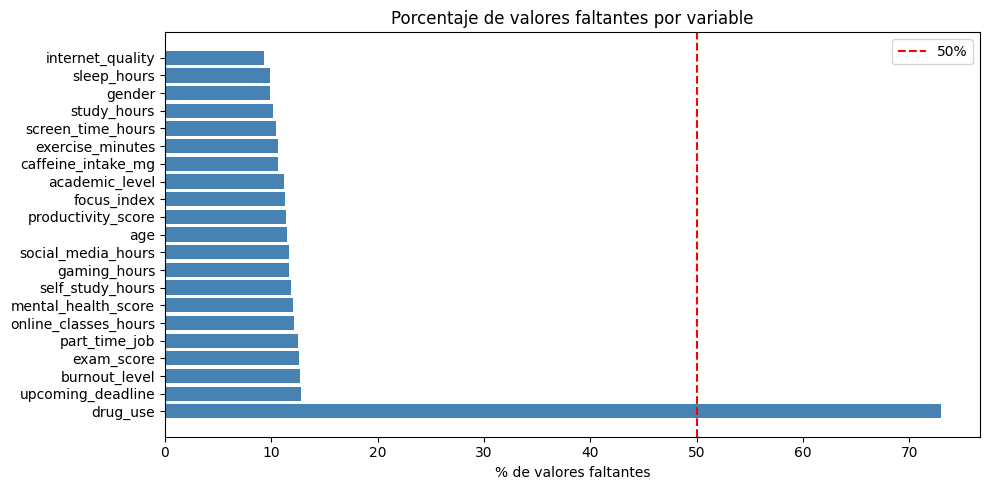

In [55]:
missing = data_raw.isnull().sum()
missing_pct = (missing / len(data_raw) * 100).round(2)
missing_df = pd.DataFrame({'Missing N': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing N'] > 0].sort_values('Missing %', ascending=False)
print(missing_df)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(missing_df.index, missing_df['Missing %'], color='steelblue')
ax.axvline(x=50, color='red', linestyle='--', label='50%')
ax.set_xlabel('% de valores faltantes')
ax.set_title('Porcentaje de valores faltantes por variable')
ax.legend()
plt.tight_layout()
plt.show()

**Observaciones sobre datos faltantes:**
- `drug_use` tiene ~73% de valores missing, lo que la hace prácticamente inutilizable como covariable; se excluirá del análisis.
- Las demás variables presentan entre ~10% y ~13% de missing, lo que es manejable.
- `exam_score` tiene ~12.6% missing. Según el enunciado, `exam_score == 1.0` indica que el alumno no rindió el examen, por lo que los NaN en esta variable corresponden a datos sin registro, 
se excluirán al construir la variable binaria.

### 1.3 Exploración de variables categóricas

In [56]:
cat_vars = ['gender', 'academic_level', 'part_time_job', 'internet_quality']
for var in cat_vars:
    print(f'--- {var} ---')
    print(data_raw[var].value_counts(dropna=False))
    print()

--- gender ---
gender
Male      2213
Female    2181
Other      669
NaN        558
Name: count, dtype: int64

--- academic_level ---
academic_level
Postgraduate      1395
Undergraduate     1380
High School       1368
NaN                630
High School        300
Postgraduate       300
Undergraduate      248
Name: count, dtype: int64

--- part_time_job ---
part_time_job
No     1838
Yes    1753
NaN     703
yes     696
no      631
Name: count, dtype: int64

--- internet_quality ---
internet_quality
Good       1746
Average    1680
Poor       1672
NaN         523
Name: count, dtype: int64



In [57]:
data_raw['academic_level'].unique()

array(['Undergraduate', 'High School', 'Undergraduate ', 'Postgraduate',
       nan, 'High School ', 'Postgraduate '], dtype=object)

In [58]:
data_raw["part_time_job"].unique()

array(['No', 'no', 'Yes', 'yes', nan], dtype=object)

**Problemas detectados en variables categóricas:**
- `academic_level`: contiene categorías con espacios en blanco al final (`'Undergraduate '`, `'High School '`, `'Postgraduate '`). Se aplicará `.str.strip()`.
- `part_time_job`: mezcla de mayúsculas/minúsculas (`'Yes'/'yes'`, `'No'/'no'`). Se estandarizará.

### 1.4 Limpieza de datos

In [59]:
df = data_raw.copy()

df['academic_level'] = df['academic_level'].str.strip()
df['part_time_job']  = df['part_time_job'].str.strip().str.capitalize()  

df['took_exam'] = np.where(
    df['exam_score'].isna(), np.nan,
    np.where(df['exam_score'] == 1.0, 0, 1)
)

print('Distribución de took_exam:')
print(df['took_exam'].value_counts(dropna=False))
print()
print(f"Rindieron el examen  (1): {(df['took_exam']==1).sum()}")
print(f"No rindieron         (0): {(df['took_exam']==0).sum()}")
print(f"Sin información    (NaN): {df['took_exam'].isna().sum()}")

Distribución de took_exam:
took_exam
1.0000    4473
NaN        709
0.0000     439
Name: count, dtype: int64

Rindieron el examen  (1): 4473
No rindieron         (0): 439
Sin información    (NaN): 709


Se limpian las variables problemáticas `academic_level` y `part_time_job` estandarizando las respuestas. Se crea además la variable `took_exam` la cual depende de `examen_score`.

Según el enunciado, `exam_score == 1.0` identifica a los estudiantes que no rindieron el examen. Por tanto:

- `took_exam = 1`: el estudiante rindió el examen (exam_score > 1.0)
- `took_exam = 0`: el estudiante no rindió el examen (exam_score == 1.0)
- `took_exam = NaN`: dato faltante en exam_score, se excluirá de los modelos

Esta variable binaria será la variable dependiente en las preguntas 2, 3 y 4.

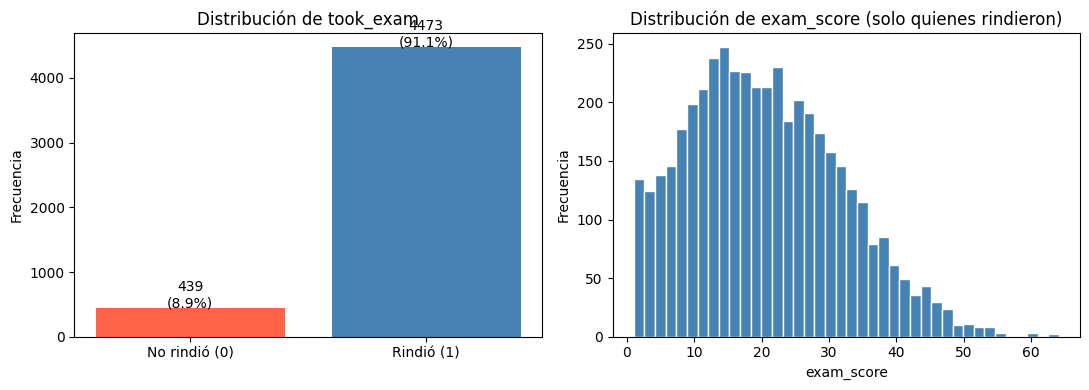

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

vals = df['took_exam'].value_counts(dropna=True)
axes[0].bar(['No rindió (0)', 'Rindió (1)'], vals.sort_index().values, color=['tomato','steelblue'])
axes[0].set_title('Distribución de took_exam')
axes[0].set_ylabel('Frecuencia')
for bar, v in zip(axes[0].patches, vals.sort_index().values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{v}\n({v/vals.sum()*100:.1f}%)', ha='center', fontsize=10)

scores = df.loc[df['took_exam'] == 1, 'exam_score']
axes[1].hist(scores, bins=40, color='steelblue', edgecolor='white')
axes[1].set_title('Distribución de exam_score (solo quienes rindieron)')
axes[1].set_xlabel('exam_score')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

In [61]:
# 1. Eliminamos la palabra 'min' (sin importar mayúsculas/minúsculas)
# 2. Eliminamos los espacios en blanco sobrantes a los lados con .strip()
# 3. Convertimos a numérico (float64)
df['exercise_minutes'] = (
    df['exercise_minutes'].str.replace('min', '', case=False, regex=False).str.strip()
)

# Convertir a float
df['exercise_minutes'] = pd.to_numeric(df['exercise_minutes'], errors='coerce')
df['exercise_minutes'].dtype

df['exercise_hours'] = df['exercise_minutes'] / 60
df['exercise_hours'].dtype

dtype('float64')

La variable `exercise_minutes` contiene sufijos de texto ('min'), lo cual impide su correcta clasificación numérica. Para solucionar esto, se eliminaron los espacios en blanco y la cadena 'min', transformando posteriormente el campo al tipo de dato `float`. Tras corregir las inconsistencias y eliminar los registros faltantes, se presentan las distribuciones reales de las variables categóricas. Por último, esta se transforma en horas, creando `exercise_hours` para mantener la estructura de las otras variables.

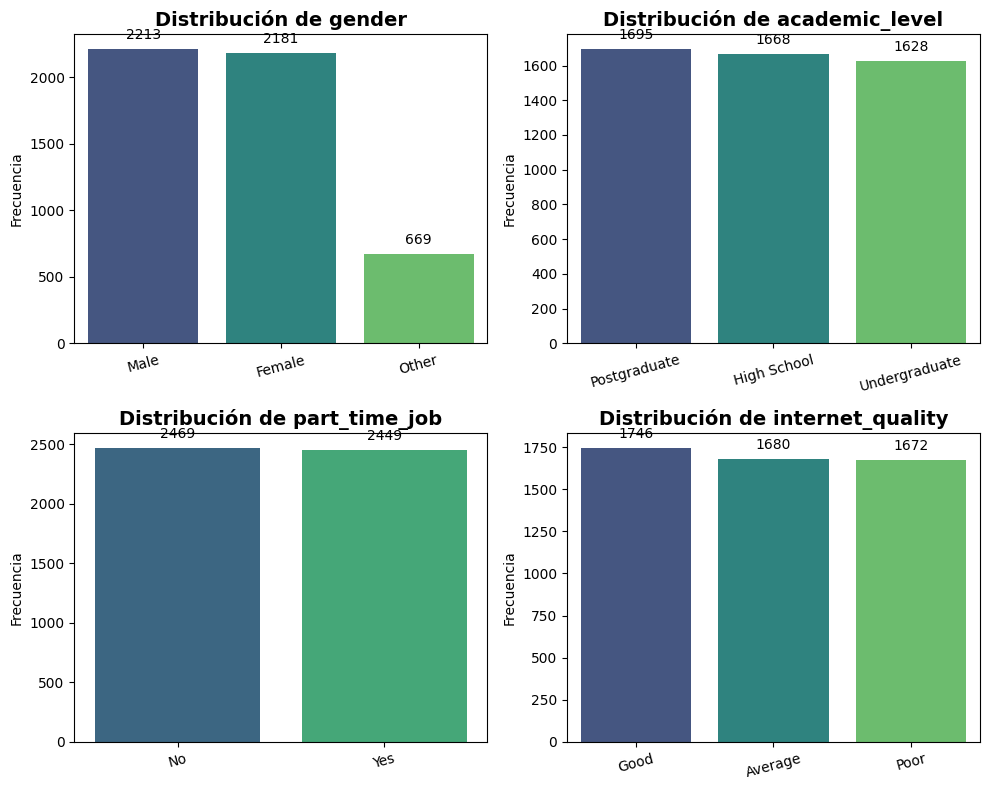

In [62]:
cat_vars = ['gender', 'academic_level', 'part_time_job', 'internet_quality']

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes = axes.flatten()

for i, var in enumerate(cat_vars):
    counts = df[var].value_counts(dropna=False)
    
    sns.barplot(x=counts.index, y=counts.values, ax=axes[i], palette='viridis', hue=counts.index, legend=False)
    
    axes[i].set_title(f'Distribución de {var}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frecuencia')
    axes[i].tick_params(axis='x', rotation=15) 
    
    for p in axes[i].patches:
        axes[i].annotate(f'{int(p.get_height())}', 
                         (p.get_x() + p.get_width() / 2., p.get_height()), 
                         ha='center', va='bottom', fontsize=10, xytext=(0, 5),
                         textcoords='offset points')

plt.tight_layout()
plt.show()

### 1.5 Estadísticas descriptivas de variables numéricas

In [63]:
num_vars = ['age', 'study_hours', 'self_study_hours', 'online_classes_hours',
            'social_media_hours', 'gaming_hours', 'screen_time_hours',
            'sleep_hours', 'exercise_hours', 'caffeine_intake_mg',
            'mental_health_score', 'focus_index', 'burnout_level',
            'productivity_score', 'exam_score']

desc = df[num_vars].describe().T
desc['skewness'] = df[num_vars].skew().round(3)
desc['kurtosis'] = df[num_vars].kurt().round(3)
pd.options.display.float_format = '{:.2f}'.format
desc

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
age,4973.00,20.51,2.88,16.00,18.00,20.00,23.00,25.00,-0.01,-1.24
study_hours,5047.00,4.54,1.82,0.00,3.26,4.53,5.76,11.84,0.06,-0.12
self_study_hours,4954.00,2.48,1.18,0.00,1.66,2.48,3.28,7.41,0.09,-0.29
online_classes_hours,4939.00,2.01,0.98,0.00,1.32,2.01,2.69,6.00,0.12,-0.27
social_media_hours,4965.00,3.00,1.47,0.00,2.00,2.99,4.03,8.28,0.12,-0.20
gaming_hours,4965.00,1.57,1.11,0.00,0.68,1.50,2.35,5.64,0.43,-0.35
screen_time_hours,5035.00,6.98,2.48,1.00,5.28,6.95,8.71,15.30,0.00,-0.24
sleep_hours,5068.00,7.02,1.16,4.00,6.25,7.01,7.82,10.00,0.01,-0.15
exercise_hours,5022.00,1.24,0.72,0.00,0.62,1.25,1.87,2.48,-0.00,-1.19
caffeine_intake_mg,5021.00,250.80,143.69,0.00,129.00,251.00,375.00,499.00,-0.02,-1.19


### 1.6 Distribuciones de variables clave

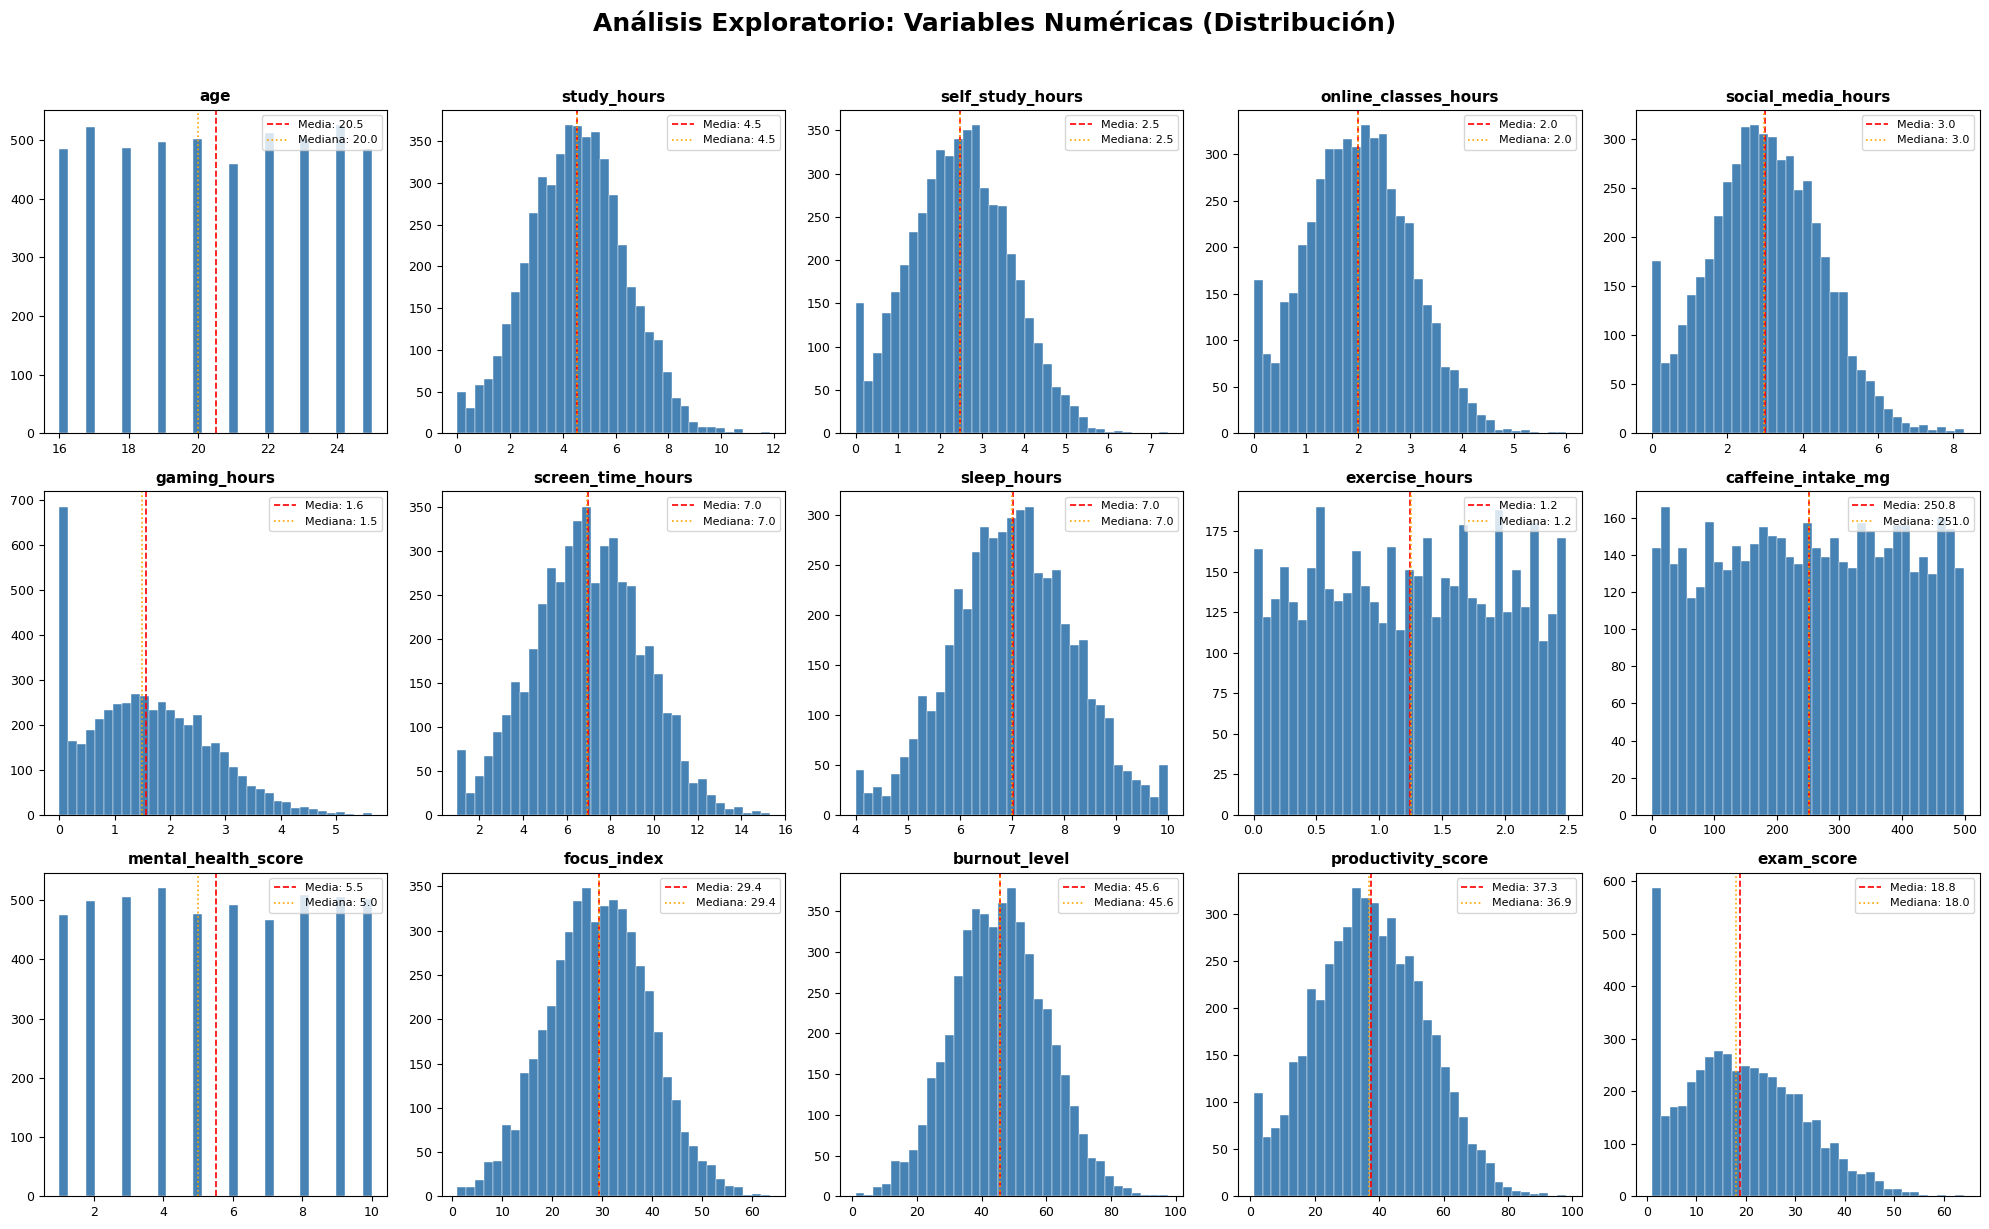

In [64]:
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

for i, var in enumerate(num_vars):

    ax = axes[i]
    data = df[var].dropna()
    ax.hist(data, bins=35, color='steelblue', edgecolor='white', linewidth=0.3)
    mean_val = data.mean()
    median_val = data.median()
    
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.2, 
               label=f'Media: {mean_val:.1f}')
    ax.axvline(median_val, color='orange', linestyle=':', linewidth=1.2, 
               label=f'Mediana: {median_val:.1f}')
    
    ax.set_title(f'{var}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, loc='upper right')
    ax.tick_params(axis='both', labelsize=9)


plt.suptitle('Análisis Exploratorio: Variables Numéricas (Distribución)', 
             fontsize=18, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

### 1.7 Detección de outliers (método IQR)

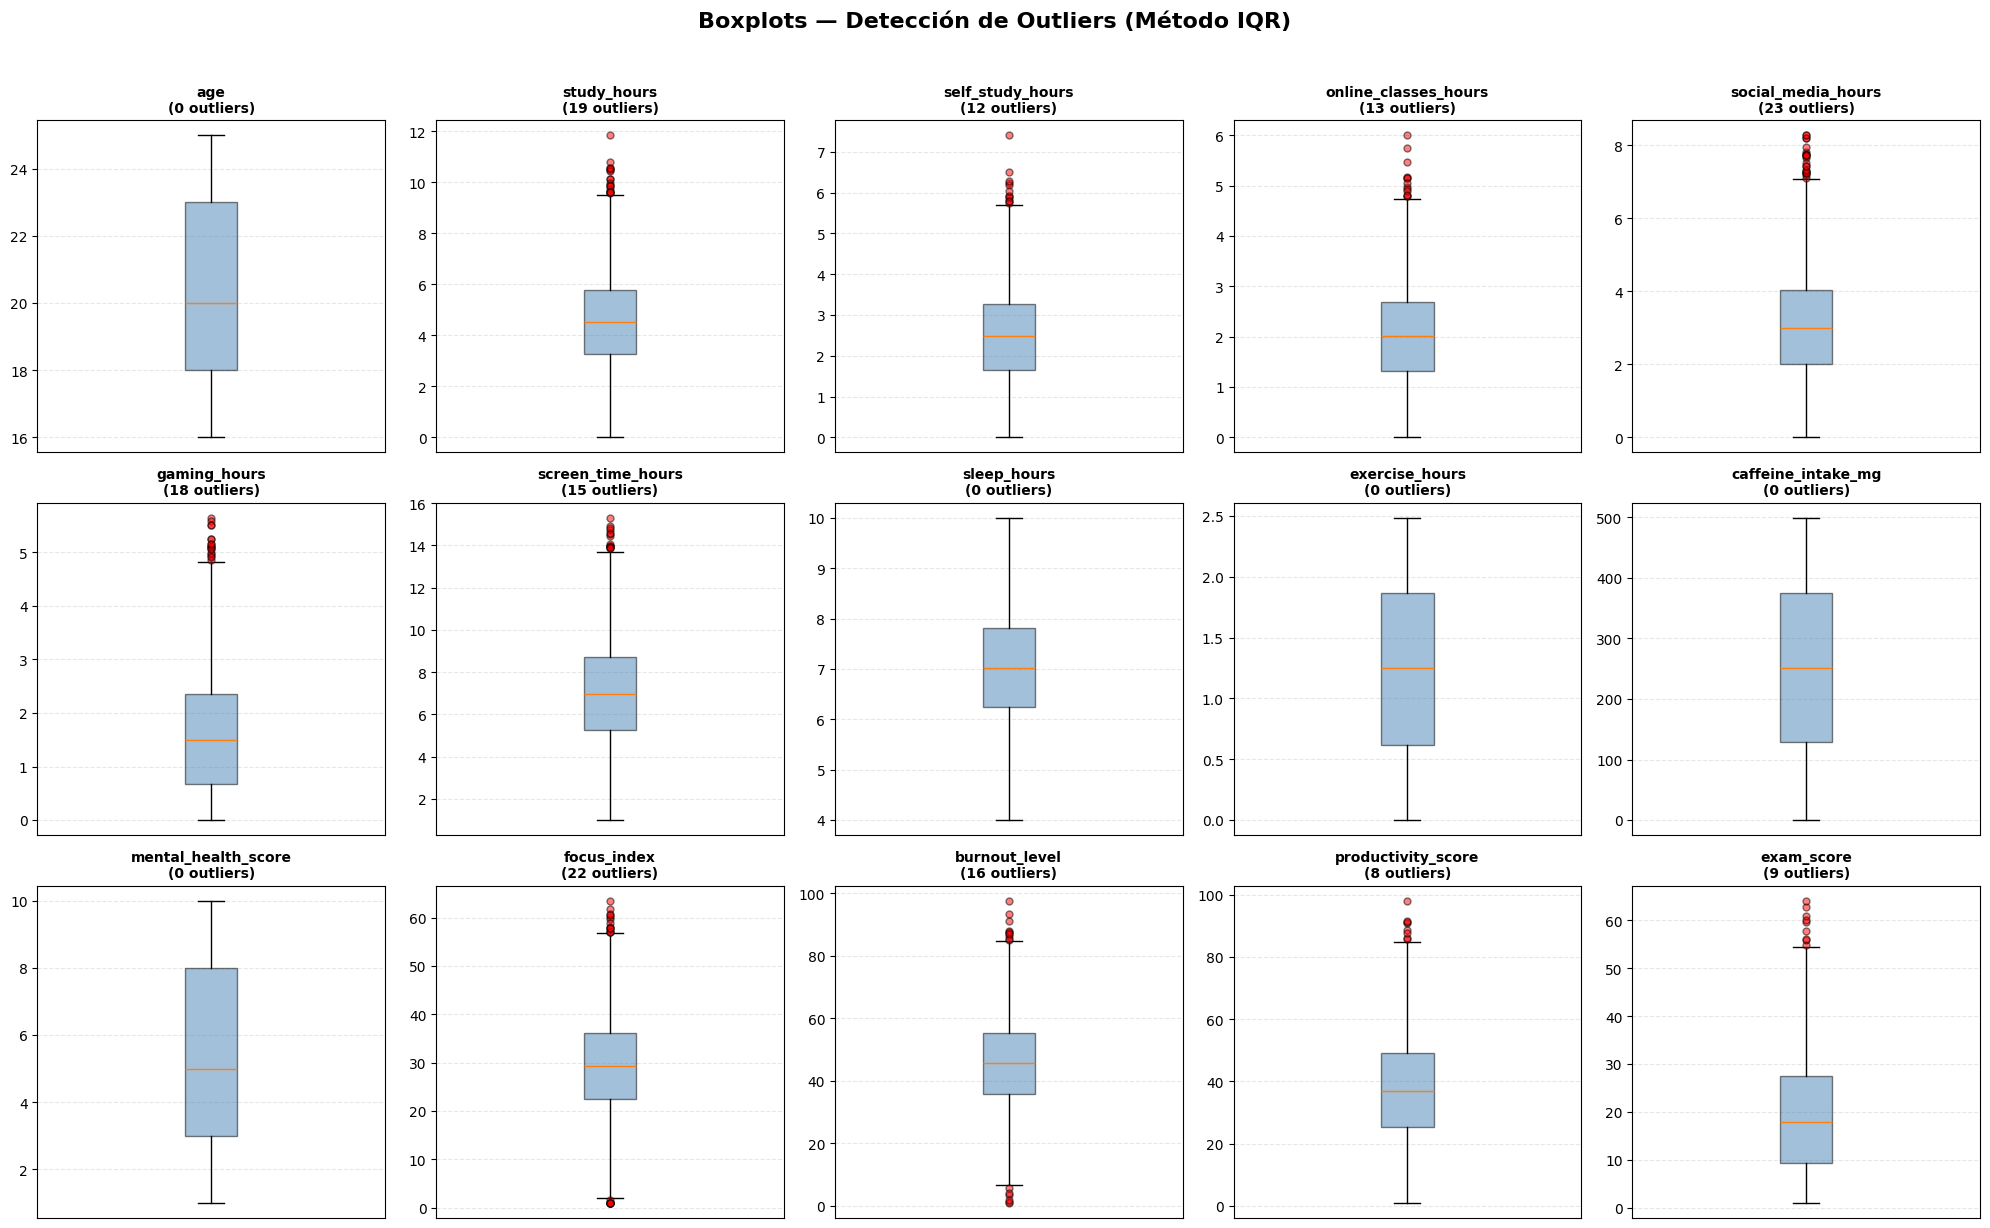


Resumen de outliers (método IQR):
                      N outliers
social_media_hours         23.00
focus_index                22.00
study_hours                19.00
gaming_hours               18.00
burnout_level              16.00
screen_time_hours          15.00
online_classes_hours       13.00
self_study_hours           12.00
exam_score                  9.00
productivity_score          8.00
age                         0.00
mental_health_score         0.00
caffeine_intake_mg          0.00
exercise_hours              0.00
sleep_hours                 0.00


In [65]:
n_cols = 5
n_vars = len(num_vars)
n_rows = (n_vars + n_cols - 1) // n_cols 

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

outlier_summary = {}

for i, var in enumerate(num_vars):
    ax = axes[i]
    data = df[var].dropna()

    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((data < lower) | (data > upper)).sum()
    
    outlier_summary[var] = {
        'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
        'N outliers': n_out
    }
    

    ax.boxplot(data, vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.5),
               flierprops=dict(marker='o', markerfacecolor='red', markersize=5, alpha=0.5))
    
    ax.set_title(f'{var}\n({n_out} outliers)', fontsize=10, fontweight='bold')
    ax.set_xticks([])
    ax.grid(axis='y', linestyle='--', alpha=0.3)


plt.suptitle('Boxplots — Detección de Outliers (Método IQR)', fontsize=16, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nResumen de outliers (método IQR):')
out_df = pd.DataFrame(outlier_summary).T
print(out_df[['N outliers']].sort_values(by='N outliers', ascending=False).to_string())

Las variables de comportamiento (horas de estudio, sueño, redes sociales, etc.) muestran outliers leves que pueden ser perfectamente válidos en una población estudiantil heterogénea (ej. alguien que duerme 12h o estudia 0h). Se opta por no eliminar estos registros para no introducir sesgo de selección, considerando además que los modelos de regresión son relativamente robustos a outliers moderados cuando el tamaño muestral es grande.

### 1.9 Preparación del dataset para modelamiento

In [66]:
model_vars = ['took_exam', 'age', 'gender', 'academic_level',
              'study_hours', 'self_study_hours', 'online_classes_hours',
              'social_media_hours', 'gaming_hours', 'screen_time_hours',
              'sleep_hours', 'exercise_hours', 'caffeine_intake_mg',
              'part_time_job', 'upcoming_deadline', 'internet_quality',
              'mental_health_score', 'focus_index', 'burnout_level',
              'productivity_score']

df_model = df[model_vars].dropna(subset=['took_exam']).copy()

df_model = pd.get_dummies(df_model,
                          columns=['gender', 'academic_level', 'part_time_job', 'internet_quality'],
                          drop_first=True,
                          dtype=float)

n_before = len(df_model)
df_model = df_model.dropna()
n_after  = len(df_model)

print(f'Observaciones antes de dropna: {n_before}')
print(f'Observaciones después de dropna: {n_after}')
print(f'Observaciones eliminadas: {n_before - n_after}')
print()
print('Columnas del dataset de modelamiento:')
print(list(df_model.columns))

Observaciones antes de dropna: 4912
Observaciones después de dropna: 4027
Observaciones eliminadas: 885

Columnas del dataset de modelamiento:
['took_exam', 'age', 'study_hours', 'self_study_hours', 'online_classes_hours', 'social_media_hours', 'gaming_hours', 'screen_time_hours', 'sleep_hours', 'exercise_hours', 'caffeine_intake_mg', 'upcoming_deadline', 'mental_health_score', 'focus_index', 'burnout_level', 'productivity_score', 'gender_Male', 'gender_Other', 'academic_level_Postgraduate', 'academic_level_Undergraduate', 'part_time_job_Yes', 'internet_quality_Good', 'internet_quality_Poor']


Se seleccionaron las variables predictoras relevantes, excluyendo aquellas con alta tasa de valores faltantes (`drug_use`) o que no aportan valor predictivo (`student_id`). El procesamiento incluyó:

- Filtrado inicial: Selección de observaciones con la variable objetivo took_exam disponible.
- Codificación categórica: Aplicación de one-hot encoding (variables dummy) para convertir atributos cualitativos en numéricos, utilizando drop_first=True para evitar la multicolinealidad.
- Limpieza final: Ejecución de una eliminación por lista (listwise deletion) para asegurar un conjunto de datos completo para el entrenamiento del modelo.

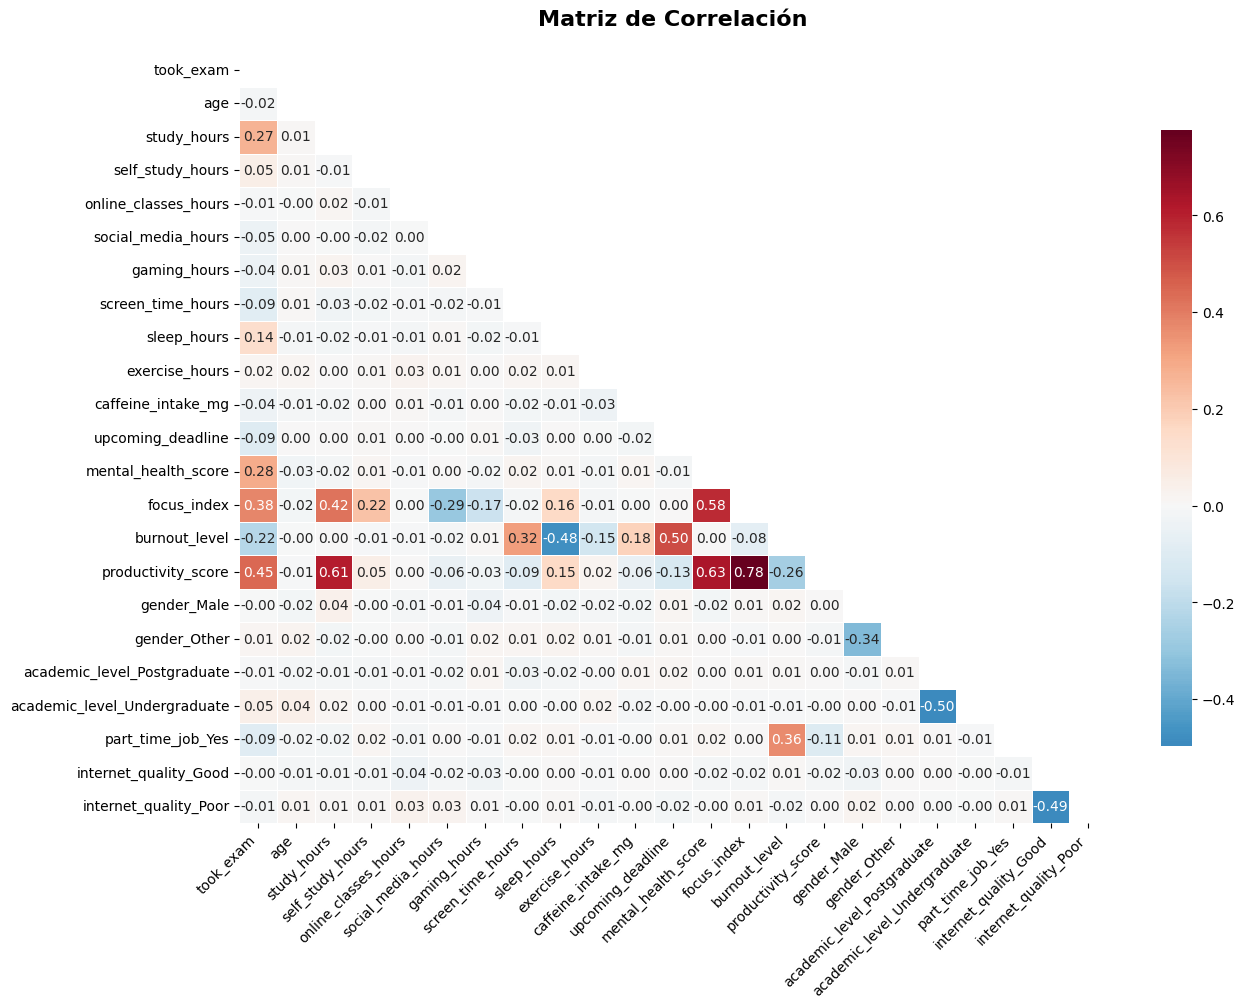


Top correlaciones con took_exam:
took_exam                       1.00
productivity_score              0.45
focus_index                     0.38
mental_health_score             0.28
study_hours                     0.27
sleep_hours                     0.14
self_study_hours                0.05
academic_level_Undergraduate    0.05
exercise_hours                  0.02
gender_Other                    0.01
gender_Male                    -0.00
internet_quality_Good          -0.00
academic_level_Postgraduate    -0.01
online_classes_hours           -0.01
internet_quality_Poor          -0.01
age                            -0.02
caffeine_intake_mg             -0.04
gaming_hours                   -0.04
social_media_hours             -0.05
screen_time_hours              -0.09
part_time_job_Yes              -0.09
upcoming_deadline              -0.09
burnout_level                  -0.22
Name: took_exam, dtype: float64


In [67]:
df_corr = df_model.copy()
corr_matrix = df_corr.corr(method='spearman')

plt.figure(figsize=(14, 10))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, 
            mask=mask,
            annot=True,           # Muestra los valores
            fmt=".2f",            # 2 decimales
            cmap='RdBu_r',        # Rojo (negativo) a Azul (positivo)
            center=0,
            linewidths=0.5,
            cbar_kws={"shrink": .8})

plt.title('Matriz de Correlación', 
          fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.show()

target = 'took_exam'
if target in corr_matrix.columns:
    print(f"\nTop correlaciones con {target}:")
    print(corr_matrix[target].sort_values(ascending=False))

---
## Pregunta 2: Modelo de Probabilidad Lineal (MCO)

El **Modelo de Probabilidad Lineal (MPL)** estima directamente la probabilidad de que un estudiante rinda el examen mediante MCO, tratando la variable binaria `took_exam` como variable dependiente continua. Su forma es:

$$P(\text{took\_exam}_i = 1 \mid X_i) = X_i'\beta$$

Una limitación conocida del MPL es que puede predecir probabilidades fuera del rango [0,1]. Se utilizarán errores estándar robustos (HC3) para corregir la heteroscedasticidad inherente al modelo.

In [68]:
y = df_model['took_exam']
X_cols = [c for c in df_model.columns if c != 'took_exam']
X = sm.add_constant(df_model[X_cols])

lpm_full = sm.OLS(y, X).fit(cov_type='HC3')
print(lpm_full.summary())

                            OLS Regression Results                            
Dep. Variable:              took_exam   R-squared:                       0.248
Model:                            OLS   Adj. R-squared:                  0.244
Method:                 Least Squares   F-statistic:                     26.91
Date:              lun., 20 abr. 2026   Prob (F-statistic):          4.93e-103
Time:                        18:52:10   Log-Likelihood:                -47.694
No. Observations:                4027   AIC:                             141.4
Df Residuals:                    4004   BIC:                             286.3
Df Model:                          22                                         
Covariance Type:                  HC3                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

Debemos quedarnos con las variables significativas, las cuales tienen un P-value menor a 0.05. Al observar la salida del modelo con todas las variables, la gran mayoría no son significativas, por lo que nos quedamos con las variables:

- `focus_index`
- `burnout_level`
- `productivity_score`
- `academic_level_Undergraduate`

In [69]:
y = df_model['took_exam']
X_cols = ['focus_index', 'burnout_level', 'productivity_score', 'academic_level_Undergraduate']
X = sm.add_constant(df_model[X_cols])

lpm_reduced = sm.OLS(y, X).fit(cov_type='HC3')
print(lpm_reduced.summary())

                            OLS Regression Results                            
Dep. Variable:              took_exam   R-squared:                       0.247
Model:                            OLS   Adj. R-squared:                  0.246
Method:                 Least Squares   F-statistic:                     148.2
Date:              lun., 20 abr. 2026   Prob (F-statistic):          2.10e-118
Time:                        18:52:11   Log-Likelihood:                -52.604
No. Observations:                4027   AIC:                             115.2
Df Residuals:                    4022   BIC:                             146.7
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

#### Análisis del modelo

- El modelo explica el 24.7% de la probabilidad de que un alumno rinda el examen. Es un valor sólido para un Modelo de Probabilidad Lineal (MPL) en ciencias sociales/comportamiento.
- Prob (F-statistic) es prácticamente cero, lo que indica que el conjunto de variables seleccionadas explica de manera real y no aleatoria el fenómeno.
- Se mantiene el uso de errores estándar HC3, lo cual es correcto para corregir la heterocedasticidad intrínseca del MPL.

#### Interpretación de los coeficientes

- Productivity Score (0.0057): Es el factor positivo con mayor peso unitario. Por cada punto que aumenta el score de productividad, la probabilidad de rendir el examen aumenta en 0.57 puntos porcentuales. Un incremento de 10 puntos en productividad subiría la probabilidad en un 5.7%.

- Focus Index (0.0038): Un mayor nivel de enfoque favorece la asistencia. Por cada punto adicional en este índice, la probabilidad de rendir aumenta en 0.38 puntos porcentuales.

- Burnout Level (-0.0025): Es el único factor disuasorio. Por cada punto de aumento en el nivel de agotamiento o "burnout", la probabilidad de rendir el examen disminuye en 0.25 puntos porcentuales.

- Academic Level Undergraduate (0.0271): Los estudiantes de grado (undergraduate) tienen una probabilidad 2.71 puntos porcentuales mayor de rendir el examen en comparación con el nivel de referencia (otros niveles académicos), manteniendo el resto de las variables constantes.

- Constante (0.6929): Representa la probabilidad base. Si un estudiante tuviera valores de cero en enfoque, productividad y burnout (y no fuera de grado), su probabilidad de rendir sería del 69.29%.

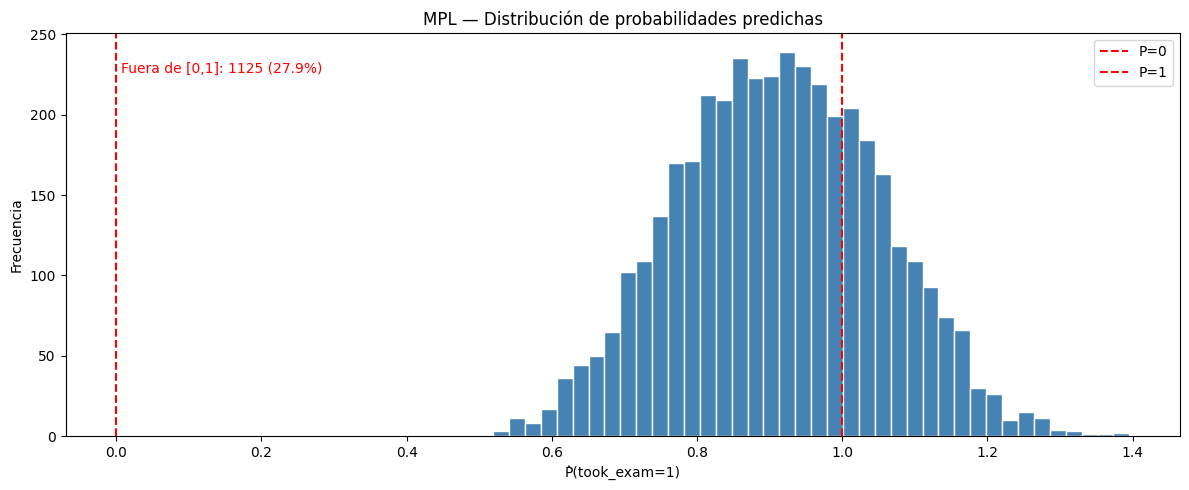


Predicciones fuera del rango [0,1]: 1125 (27.9%)


In [70]:
y_hat_lpm = lpm_reduced.fittedvalues

fig, ax = plt.subplots(1, 1, figsize=(12, 5))

ax.hist(y_hat_lpm, bins=40, color='steelblue', edgecolor='white')
ax.axvline(0, color='red', linestyle='--', label='P=0')
ax.axvline(1, color='red', linestyle='--', label='P=1')
ax.set_title('MPL — Distribución de probabilidades predichas')
ax.set_xlabel('P̂(took_exam=1)')
ax.set_ylabel('Frecuencia')
ax.legend()

n_out_range = ((y_hat_lpm < 0) | (y_hat_lpm > 1)).sum()
pct_out_range = (n_out_range / len(y_hat_lpm)) * 100

ax.text(0.05, 0.9, f'Fuera de [0,1]: {n_out_range} ({pct_out_range:.1f}%)',
        transform=ax.transAxes, color='red')

plt.tight_layout()
plt.show()

print(f'\nPredicciones fuera del rango [0,1]: {n_out_range} ({pct_out_range:.1f}%)')

---
## Pregunta 3: Modelo Probit

El modelo Probit modela la probabilidad de rendir el examen usando la función de distribución acumulada de la normal estándar $\Phi(\cdot)$:

$$P(\text{took\_exam}_i = 1 \mid X_i) = \Phi(X_i'\beta)$$

Esto garantiza predicciones dentro de [0,1] y es estimado por máxima verosimilitud. Los coeficientes **no se interpretan directamente** como efectos marginales; para ello se calculan los **efectos marginales en la media (MEM)**.

In [71]:
y = df_model['took_exam']
X_cols = [c for c in df_model.columns if c != 'took_exam']

X_probit = sm.add_constant(df_model[X_cols])

probit_model = sm.Probit(y, X_probit)
probit_res   = probit_model.fit(maxiter=200, disp=True)
print(probit_res.summary())

Optimization terminated successfully.
         Current function value: 0.120095
         Iterations 9
                          Probit Regression Results                           
Dep. Variable:              took_exam   No. Observations:                 4027
Model:                         Probit   Df Residuals:                     4004
Method:                           MLE   Df Model:                           22
Date:              lun., 20 abr. 2026   Pseudo R-squ.:                  0.5950
Time:                        18:52:11   Log-Likelihood:                -483.62
converged:                       True   LL-Null:                       -1194.0
Covariance Type:            nonrobust   LLR p-value:                2.751e-287
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                           -0.2280      0.692     -0.329      0.742

Al igual que en el modelo anterior, las variables con P-value ($P>|z|$) < 0.05 son las que debemos incluir en un modelo final:

- `focus_index`
- `burnout_level`
- `productivity_score`
- `academic_level_Undergraduate`

In [72]:
y = df_model['took_exam']
X_cols = ['focus_index', 'burnout_level', 'productivity_score', 'academic_level_Undergraduate']

X_probit_red = sm.add_constant(df_model[X_cols])

probit_model = sm.Probit(y, X_probit_red)
probit_res   = probit_model.fit(maxiter=200, disp=True)
print(probit_res.summary())

mfx = probit_res.get_margeff()
print(mfx.summary())

Optimization terminated successfully.
         Current function value: 0.122171
         Iterations 9
                          Probit Regression Results                           
Dep. Variable:              took_exam   No. Observations:                 4027
Model:                         Probit   Df Residuals:                     4022
Method:                           MLE   Df Model:                            4
Date:              lun., 20 abr. 2026   Pseudo R-squ.:                  0.5880
Time:                        18:52:11   Log-Likelihood:                -491.98
converged:                       True   LL-Null:                       -1194.0
Covariance Type:            nonrobust   LLR p-value:                9.017e-303
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                           -0.2687      0.208     -1.289      0.197

Pseudo R² de McFadden: 0.5880
Log-likelihood:        -491.98
AIC:                   993.97
BIC:                   1025.47
Accuracy (umbral 0.5): 0.9469


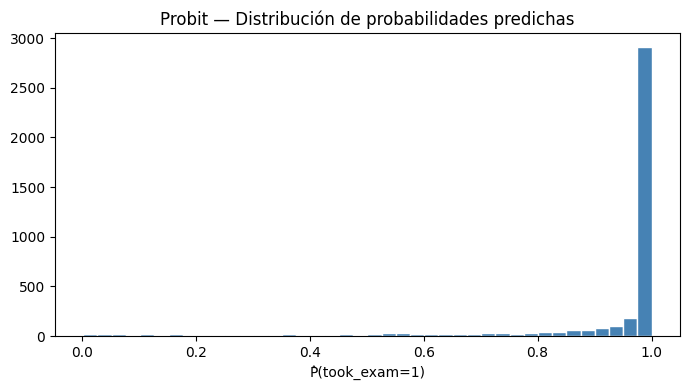

In [73]:
y_hat_probit = probit_res.predict(X_probit_red)
y_pred_probit = (y_hat_probit >= 0.5).astype(int)
acc_probit = (y_pred_probit == y).mean()

print(f'Pseudo R² de McFadden: {probit_res.prsquared:.4f}')
print(f'Log-likelihood:        {probit_res.llf:.2f}')
print(f'AIC:                   {probit_res.aic:.2f}')
print(f'BIC:                   {probit_res.bic:.2f}')
print(f'Accuracy (umbral 0.5): {acc_probit:.4f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(y_hat_probit, bins=40, color='steelblue', edgecolor='white')
ax.set_title('Probit — Distribución de probabilidades predichas')
ax.set_xlabel('P̂(took_exam=1)')
plt.tight_layout()
plt.show()

#### Análisis del modelo

- El Pseudo R-squared (0.588) indica un ajuste muy alto.
- El modelo es extremadamente robusto. Todas las variables seleccionadas tienen un P-value de 0.000 (o 0.005 para Undergraduate).
- El modelo advierte que predice perfectamente el 45% de los casos.

#### Interpretación de los coeficientes

- Productivity Score (0.0068): Es la variable con mayor impacto. Por cada punto adicional en el score de productividad, la probabilidad de rendir el examen aumenta en 0.68 puntos porcentuales.

- Focus Index (0.0034): Por cada punto extra en el índice de enfoque, la probabilidad de rendir aumenta en 0.34 puntos porcentuales.

- Burnout Level (-0.0024): Por cada punto que aumenta el nivel de agotamiento, la probabilidad de rendir disminuye en 0.24 puntos porcentuales.

- Academic Level Undergraduate (0.0182): Manteniendo constante el nivel de productividad, enfoque y burnout, ser un estudiante de grado (undergraduate) aumenta la probabilidad de rendir en 1.82 puntos porcentuales en comparación con otros niveles académicos.

---
## Pregunta 4: Modelo Logit

El modelo **Logit** utiliza la función logística $\Lambda(\cdot)$ como función de enlace:

$$P(\text{took\_exam}_i = 1 \mid X_i) = \Lambda(X_i'\beta) = \frac{e^{X_i'\beta}}{1 + e^{X_i'\beta}}$$

Al igual que el Probit, es estimado por máxima verosimilitud y garantiza predicciones en [0,1]. Los coeficientes se pueden interpretar también en términos de **odds ratios** ($e^{\hat{\beta}}$), y los efectos marginales se calculan de manera análoga.

In [74]:
y = df_model['took_exam']
X_cols = [c for c in df_model.columns if c != 'took_exam']

X_logit = sm.add_constant(df_model[X_cols])

logit_model = sm.Logit(y, X_logit)
logit_res = logit_model.fit(maxiter=200, disp=True)
print(logit_res.summary())

mfx = logit_res.get_margeff()
print(mfx.summary())

Optimization terminated successfully.
         Current function value: 0.120457
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:              took_exam   No. Observations:                 4027
Model:                          Logit   Df Residuals:                     4004
Method:                           MLE   Df Model:                           22
Date:              lun., 20 abr. 2026   Pseudo R-squ.:                  0.5937
Time:                        18:52:11   Log-Likelihood:                -485.08
converged:                       True   LL-Null:                       -1194.0
Covariance Type:            nonrobust   LLR p-value:                1.154e-286
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                           -0.5953      1.265     -0.471      0.63

Al igual que en los modelos anteriores, las variables con P-value ($P>|z|$) < 0.05 son las que debemos incluir en un modelo final:

- `focus_index`
- `burnout_level`
- `productivity_score`
- `academic_level_Undergraduate`

In [75]:
y = df_model['took_exam']
X_cols = ['focus_index', 'burnout_level', 'productivity_score', 'academic_level_Undergraduate']

X_logit_red = sm.add_constant(df_model[X_cols])

logit_model = sm.Logit(y, X_logit_red)
logit_res = logit_model.fit(maxiter=200, disp=True)
print(logit_res.summary())

mfx = logit_res.get_margeff()
print(mfx.summary())

Optimization terminated successfully.
         Current function value: 0.122633
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:              took_exam   No. Observations:                 4027
Model:                          Logit   Df Residuals:                     4022
Method:                           MLE   Df Model:                            4
Date:              lun., 20 abr. 2026   Pseudo R-squ.:                  0.5864
Time:                        18:52:11   Log-Likelihood:                -493.84
converged:                       True   LL-Null:                       -1194.0
Covariance Type:            nonrobust   LLR p-value:                5.787e-302
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                           -0.5585      0.380     -1.471      0.14

In [76]:
params = logit_res.params

odds_ratios = np.exp(params)

conf = logit_res.conf_int()
conf_or = np.exp(conf)

or_summary = pd.concat([odds_ratios, conf_or], axis=1)
or_summary.columns = ['Odds Ratio', 'CI 2.5%', 'CI 97.5%']

print(or_summary)

                              Odds Ratio  CI 2.5%  CI 97.5%
const                               0.57     0.27      1.20
focus_index                         1.10     1.07      1.13
burnout_level                       0.94     0.92      0.95
productivity_score                  1.20     1.18      1.23
academic_level_Undergraduate        1.61     1.13      2.29


Pseudo R² de McFadden: 0.5864
Log-likelihood:        -493.84
AIC:                   997.69
BIC:                   1029.19
Accuracy (umbral 0.5): 0.9466


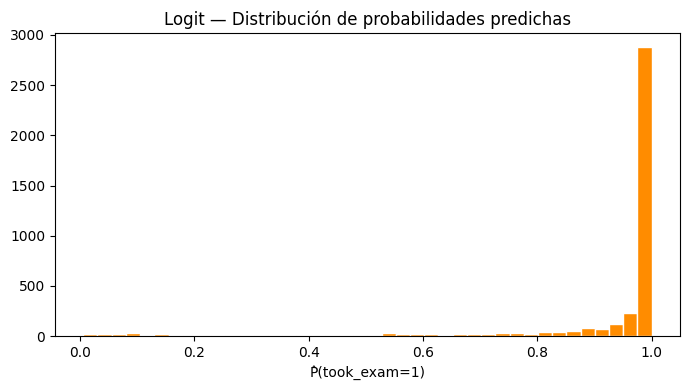

In [77]:
y_hat_logit  = logit_res.predict(X_logit_red)
y_pred_logit = (y_hat_logit >= 0.5).astype(int)
acc_logit    = (y_pred_logit == y).mean()

print(f'Pseudo R² de McFadden: {logit_res.prsquared:.4f}')
print(f'Log-likelihood:        {logit_res.llf:.2f}')
print(f'AIC:                   {logit_res.aic:.2f}')
print(f'BIC:                   {logit_res.bic:.2f}')
print(f'Accuracy (umbral 0.5): {acc_logit:.4f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(y_hat_logit, bins=40, color='darkorange', edgecolor='white')
ax.set_title('Logit — Distribución de probabilidades predichas')
ax.set_xlabel('P̂(took_exam=1)')
plt.tight_layout()
plt.show()

#### Análisis del modelo

- El Pseudo R-squared (0.586) indica un ajuste muy alto y una accuracy del 94.6%
- La significancia global dada por LLR p-value es practicamente cero, lo que confirma que las variables elegidas en conjunto explican el fenómeno de manera muy potente.
- El modelo advierte que predice perfectamente el 25% de los casos.

#### Interpretación de los coeficientes

- Productivity Score:
    - AME 0.0068: Es la variable con mayor impacto. Por cada punto adicional en el score de productividad, la probabilidad de rendir el examen aumenta en 0.68 puntos porcentuales.
    - OR 1.203: Por cada punto adicional en el score de productividad, las probabilidades de tomar el examen suben un 20.3%.

- Focus Index (0.0034):
    - AME 0.0034: Por cada punto extra en el índice de enfoque, la probabilidad de rendir aumenta en 0.34 puntos porcentuales.
    - OR 1.098: Un incremento unitario en el índice de enfoque eleva las probabilidades en un 9.8%. Es positivo, aunque su impacto por unidad es menor que el de la productividad.

- Burnout Level (-0.0024):
    - AME -0.0024: Por cada punto que aumenta el nivel de agotamiento, la probabilidad de rendir disminuye en 0.24 puntos porcentuales.
    - OR 0.936: Por cada punto que sube el nivel de burnout, las probabilidades de tomar el examen disminuyen un 6.4%

- Academic Level Undergraduate (0.0182):
    - AME 0.0182: Manteniendo constante el nivel de productividad, enfoque y burnout, ser un estudiante de grado (undergraduate) aumenta la probabilidad de rendir en 1.82 puntos porcentuales en comparación con otros niveles académicos.
    - OR 1.608: Ser estudiante de pregrado (Undergraduate) aumenta las probabilidades de tomar el examen en un 60.8% en comparación con el grupo de referencia, manteniendo todo lo demás constante. Es el predictor categórico más fuerte.

---
## Pregunta 5: Comparación de Modelos y Discusión

In [78]:
lpm_coefs   = lpm_reduced.params.drop('const')
lpm_pvals   = lpm_reduced.pvalues.drop('const')

probit_me_obj = probit_res.get_margeff()
probit_me     = probit_me_obj.margeff

logit_me_obj  = logit_res.get_margeff()
logit_me      = logit_me_obj.margeff

compare_df = pd.DataFrame({
    'MPL coef.':    lpm_coefs.values,
    'MPL p-val':    lpm_pvals.values,
    'Probit dF/dx': probit_me,
    'Probit p-val': probit_me,
    'Logit dF/dx':  logit_me,
    'Logit p-val':  logit_me,
}, index=lpm_coefs.index)

pd.options.display.float_format = '{:.4f}'.format
print('Comparación de efectos marginales (en la media):')
print(compare_df.to_string())

Comparación de efectos marginales (en la media):
                              MPL coef.  MPL p-val  Probit dF/dx  Probit p-val  Logit dF/dx  Logit p-val
focus_index                      0.0038     0.0000        0.0034        0.0034       0.0034       0.0034
burnout_level                   -0.0025     0.0000       -0.0024       -0.0024      -0.0024      -0.0024
productivity_score               0.0057     0.0000        0.0068        0.0068       0.0068       0.0068
academic_level_Undergraduate     0.0271     0.0007        0.0182        0.0182       0.0175       0.0175


In [79]:
fit_table = pd.DataFrame({
    'Modelo':       ['MPL (MCO)', 'Probit', 'Logit'],
    'R²/Pseudo-R²': [lpm_reduced.rsquared,  probit_res.prsquared, logit_res.prsquared],
    'AIC':          [lpm_reduced.aic,        probit_res.aic,       logit_res.aic],
    'BIC':          [lpm_reduced.bic,        probit_res.bic,       logit_res.bic],
    'Log-lik':      [lpm_reduced.llf,        probit_res.llf,       logit_res.llf],
    'Accuracy':     [
        ((lpm_reduced.fittedvalues >= 0.5).astype(int) == y).mean(),
        acc_probit,
        acc_logit
    ]
})
print(fit_table.to_string(index=False))

   Modelo  R²/Pseudo-R²      AIC       BIC   Log-lik  Accuracy
MPL (MCO)        0.2466 115.2078  146.7117  -52.6039    0.9126
   Probit        0.5880 993.9653 1025.4692 -491.9826    0.9469
    Logit        0.5864 997.6886 1029.1925 -493.8443    0.9466


---
## Pregunta 6: Modelo Poisson para la Nota del Examen

En esta sección modelamos **la nota del examen** (`exam_score`) únicamente entre los alumnos que rindieron el examen (`took_exam == 1`).

### Consideraciones sobre el uso de Poisson

El modelo Poisson es adecuado para **datos de conteo** (enteros no negativos). Si bien `exam_score` es una variable continua, su aplicación en este contexto sigue la convención econométrica de aproximar scores discretizados mediante modelos de conteo cuando:
- Los valores son no negativos.
- La variable refleja una 'acumulación' de puntajes (eventos correctos).
- La muestra es grande y los valores mínimos están alejados de cero.

Para aplicar el modelo, **redondeamos** `exam_score` al entero más cercano. El modelo Poisson asume que:

$$E[Y_i \mid X_i] = \text{Var}(Y_i \mid X_i) = \mu_i = e^{X_i'\beta}$$

donde el supuesto clave es **equidispersión** (media = varianza). Verificaremos si este supuesto se sostiene en la pregunta 7.

In [80]:
model_vars = ['took_exam','exam_score','age', 'gender', 'academic_level',
              'study_hours', 'self_study_hours', 'online_classes_hours',
              'social_media_hours', 'gaming_hours', 'screen_time_hours',
              'sleep_hours', 'exercise_hours', 'caffeine_intake_mg',
              'part_time_job', 'upcoming_deadline', 'internet_quality',
              'mental_health_score', 'focus_index', 'burnout_level',
              'productivity_score']

df_pois = df[model_vars].dropna(subset=['took_exam']).copy()

df_pois = pd.get_dummies(df_pois,
                          columns=['gender', 'academic_level', 'part_time_job', 'internet_quality'],
                          drop_first=True,
                          dtype=float)

df_pois = df_pois.dropna()

df_pois = df_pois[df_pois['took_exam']==1].copy()

df_pois['exam_score_int'] = df_pois['exam_score'].round().astype(int)




Observaciones (rindieron examen): 3675
exam_score_int — media: 20.53, varianza: 127.35
Ratio Varianza/Media: 6.205


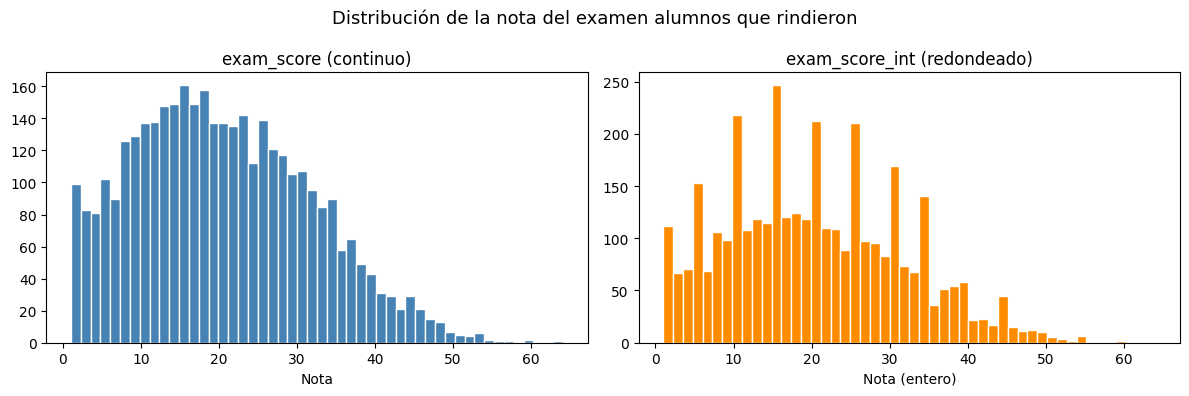

In [81]:
print(f'Observaciones (rindieron examen): {len(df_pois)}')
print(f'exam_score_int — media: {df_pois["exam_score_int"].mean():.2f}, '
      f'varianza: {df_pois["exam_score_int"].var():.2f}')
print(f'Ratio Varianza/Media: {df_pois["exam_score_int"].var() / df_pois["exam_score_int"].mean():.3f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_pois['exam_score'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('exam_score (continuo)')
axes[0].set_xlabel('Nota')

axes[1].hist(df_pois['exam_score_int'], bins=50, color='darkorange', edgecolor='white')
axes[1].set_title('exam_score_int (redondeado)')
axes[1].set_xlabel('Nota (entero)')

plt.suptitle('Distribución de la nota del examen alumnos que rindieron', fontsize=13)
plt.tight_layout()
plt.show()

In [82]:
df_pois.drop(columns=['took_exam','exam_score'], inplace=True)

In [83]:
y_count = df_pois['exam_score_int']
X_count_cols = [c for c in df_pois.columns if c != 'exam_score_int']
X_count = sm.add_constant(df_pois[X_count_cols])

poisson_full = sm.Poisson(y_count, X_count).fit()
print(poisson_full.summary())

Optimization terminated successfully.
         Current function value: 3.202671
         Iterations 6
                          Poisson Regression Results                          
Dep. Variable:         exam_score_int   No. Observations:                 3675
Model:                        Poisson   Df Residuals:                     3652
Method:                           MLE   Df Model:                           22
Date:              lun., 20 abr. 2026   Pseudo R-squ.:                  0.4313
Time:                        18:52:12   Log-Likelihood:                -11770.
converged:                       True   LL-Null:                       -20696.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                            2.0791      0.057     36.280      0.000

In [84]:
y = df_pois['exam_score_int']
X_cols = ['focus_index', 'burnout_level', 'productivity_score', 'mental_health_score']

X_poiss_red = sm.add_constant(df_pois[X_cols])

poisson_red = sm.Poisson(y, X_poiss_red).fit()
print(poisson_red.summary())

Optimization terminated successfully.
         Current function value: 3.205971
         Iterations 5
                          Poisson Regression Results                          
Dep. Variable:         exam_score_int   No. Observations:                 3675
Model:                        Poisson   Df Residuals:                     3670
Method:                           MLE   Df Model:                            4
Date:              lun., 20 abr. 2026   Pseudo R-squ.:                  0.4307
Time:                        18:52:12   Log-Likelihood:                -11782.
converged:                       True   LL-Null:                       -20696.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   2.0214      0.019    108.248      0.000       1.985       2.058
fo

In [85]:
params = poisson_red.params
conf = poisson_red.conf_int()
irr_df = np.exp(pd.concat([params, conf], axis=1))

irr_df.columns = ['IRR', 'Lower CI (95%)', 'Upper CI (95%)']
print("--- Incidence Rate Ratios ---")
print(irr_df)

marginal_effects = poisson_red.get_margeff(at='overall', method='dydx')
print("--- Efectos Marginales Promedio (AME) ---")
print(marginal_effects.summary())

--- Incidence Rate Ratios ---
                       IRR  Lower CI (95%)  Upper CI (95%)
const               7.5490          7.2777          7.8304
focus_index         1.0134          1.0122          1.0147
burnout_level       0.9908          0.9903          0.9914
productivity_score  1.0214          1.0206          1.0222
mental_health_score 1.0074          1.0040          1.0108
--- Efectos Marginales Promedio (AME) ---
       Poisson Marginal Effects      
Dep. Variable:         exam_score_int
Method:                          dydx
At:                           overall
                         dy/dx    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
focus_index             0.2738      0.013     21.581      0.000       0.249       0.299
burnout_level          -0.1894      0.006    -32.550      0.000      -0.201      -0.178
productivity_score      0.4347      0.008     51.577      0.000       

#### Interpretación de los coeficientes

- Productivity Score
    - IRR (1.02): Por cada punto extra de productividad, la nota del examen aumenta un 2%
    - AME (0.4347): En términos absolutos, un aumento de 1 punto en productividad se traduce en un incremento promedio de 0.43 puntos en la nota final.

- Focus Index:
    - IRR (1.01): Cada punto de enfoque aumenta la nota en un 1%.
    - AME (0.2738): Un punto más en el índice de enfoque sube la nota en 0.27 puntos promedio.

- Mental Health Score
    - IRR (1.01): Tiene un impacto porcentual similar al enfoque (aprox. 1%).
    - AME (0.1517): Es el impacto absoluto más bajo de los positivos, sumando 0.15 puntos por cada unidad de mejora en salud mental.

- Burnout Level
    - IRR (0.99): Por cada punto de burnout, la nota del examen cae un 1%.
    - AME (-0.1894): Cada nivel adicional de agotamiento resta, en promedio, casi 0.20 puntos de la nota del examen.

---
## Pregunta 7: Detección de Sobredispersión y Estimación de Alpha

La sobredispersión ocurre cuando $\text{Var}(Y_i \mid X_i) > E[Y_i \mid X_i]$, violando el supuesto fundamental de Poisson. En datos de conteo esto es la regla, no la excepción.

La **Binomial Negativa** generaliza el Poisson incorporando un parámetro $\alpha$ (parámetro de sobredispersión):

$$\text{Var}(Y_i \mid X_i) = \mu_i + \alpha \cdot \mu_i^2$$

Si $\alpha = 0$ → se reduce al modelo Poisson. Si $\alpha > 0$ → hay sobredispersión.

In [86]:
# Test 1: Ratio varianza/media incondicional 
mean_y = y.mean()
var_y  = y.var()
print(f'Media de exam_score_int:    {mean_y:.3f}')
print(f'Varianza de exam_score_int: {var_y:.3f}')
print(f'Ratio Varianza/Media (incondicional): {var_y/mean_y:.3f}')
print('→ Ratio >> 1 sugiere sobredispersión')

Media de exam_score_int:    20.525
Varianza de exam_score_int: 127.351
Ratio Varianza/Media (incondicional): 6.205
→ Ratio >> 1 sugiere sobredispersión


In [96]:
# Test 2: Test de Cameron & Trivedi 
# H0: equidispersión   H1: Var(Y|X) = mu + alpha * mu^2
# Auxiliar: regresar (y - mu_hat)^2 - y sobre mu_hat^2 sin constante

mu_hat = poisson_red.predict(X_poiss_red)
y_arr  = y.values

aux_y = (y_arr - mu_hat)**2 - y_arr
aux_x = mu_hat**2

aux_reg = sm.OLS(aux_y, aux_x).fit()
alpha_cameron = aux_reg.params[0]
t_cameron     = aux_reg.tvalues[0]
p_cameron     = aux_reg.pvalues[0]

print('Test de Cameron & Trivedi (1990) H0: equidispersión')
print(f'  alpha estimado:  {alpha_cameron:.4f}')
print(f'  t-statistic: {t_cameron:.3f}')
print(f'  p-value:     {p_cameron:.6f}')
print()
if p_cameron < 0.05:
    print('Se rechaza H0: existe sobredispersión significativa (alpha > 0)')
else:
    print('No se rechaza H0: no hay evidencia de sobredispersión')

Test de Cameron & Trivedi (1990) H0: equidispersión
  alpha estimado:  0.0298
  t-statistic: 28.338
  p-value:     0.000000

Se rechaza H0: existe sobredispersión significativa (alpha > 0)


C:\Users\Vicente C\AppData\Local\Temp\ipykernel_6180\1938740782.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  alpha_cameron = aux_reg.params[0]
C:\Users\Vicente C\AppData\Local\Temp\ipykernel_6180\1938740782.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  t_cameron     = aux_reg.tvalues[0]
C:\Users\Vicente C\AppData\Local\Temp\ipykernel_6180\1938740782.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_cameron     = 

In [88]:
nb_for_alpha = sm.NegativeBinomial(y, X_poiss_red).fit(disp=False)

alpha_nb = nb_for_alpha.params['alpha']
alpha_ci = nb_for_alpha.conf_int().loc['alpha']

print('Estimación de alpha (parámetro de sobredispersión) — Binomial Negativa')
print(f'  alpha estimado:      {alpha_nb:.4f}')
print(f'  IC 95%:          [{alpha_ci[0]:.4f}, {alpha_ci[1]:.4f}]')
print(f'  Var(Y|X) = mu + {alpha_nb:.4f} mu^2')
print()
print('Interpretación:')
print(f'  Un alpha = {alpha_nb:.3f} > 0 confirma sobredispersión.')
print(f'  El IC 95% no contiene el 0, lo que valida estadísticamente la sobredispersión.')

Estimación de alpha (parámetro de sobredispersión) — Binomial Negativa
  alpha estimado:      0.0285
  IC 95%:          [0.0244, 0.0326]
  Var(Y|X) = mu + 0.0285 mu^2

Interpretación:
  Un alpha = 0.028 > 0 confirma sobredispersión.
  El IC 95% no contiene el 0, lo que valida estadísticamente la sobredispersión.


c:\Users\Vicente C\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)


In [89]:
residuos_pearson = poisson_red.resid_pearson
pearson_chi2 = np.sum(residuos_pearson**2)
df_resid = poisson_red.df_resid

pearson_disp = pearson_chi2 / df_resid

print(f"Chi-cuadrado de Pearson: {pearson_chi2:.4f}")
print(f"Grados de libertad: {df_resid}")
print(f"Dispersión de Pearson: {pearson_disp:.4f}")

Chi-cuadrado de Pearson: 5914.9475
Grados de libertad: 3670.0
Dispersión de Pearson: 1.6117


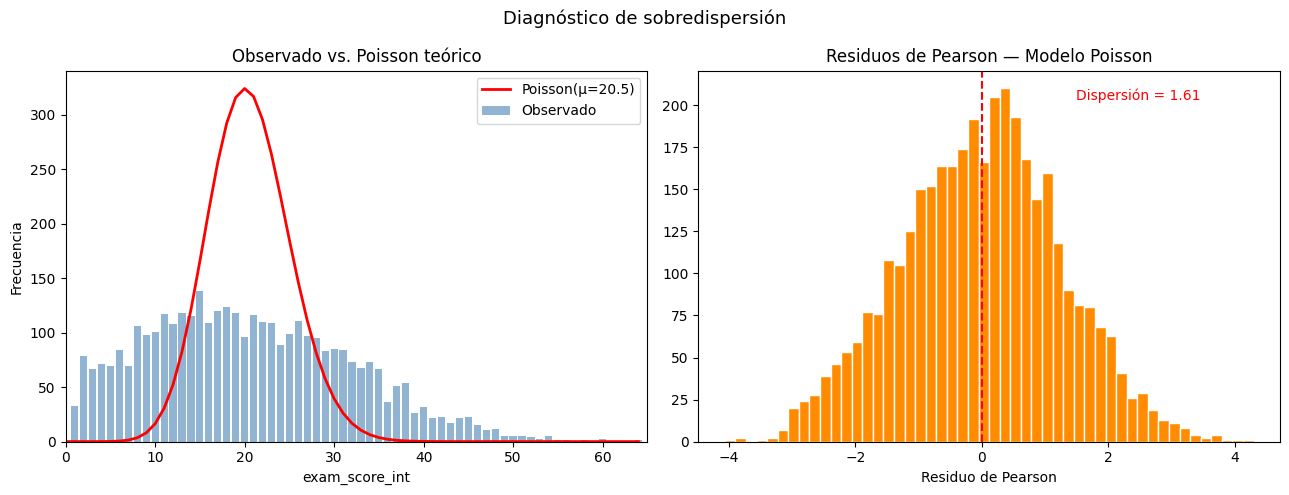

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

mu_unconditional = y_count.mean()
x_range = np.arange(0, y_count.max() + 1)
poisson_probs = sp_poisson.pmf(x_range, mu_unconditional) * len(y_count)

axes[0].bar(x_range, np.bincount(y_count.values, minlength=len(x_range)),
             color='steelblue', alpha=0.6, label='Observado')
axes[0].plot(x_range, poisson_probs, 'r-', linewidth=2, label=f'Poisson(μ={mu_unconditional:.1f})')
axes[0].set_xlim(0, 65)
axes[0].set_title('Observado vs. Poisson teórico')
axes[0].set_xlabel('exam_score_int')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

pearson_resid = poisson_red.resid_pearson
axes[1].hist(pearson_resid, bins=50, color='darkorange', edgecolor='white')
axes[1].set_title('Residuos de Pearson — Modelo Poisson')
axes[1].set_xlabel('Residuo de Pearson')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].text(0.65, 0.92, f'Dispersión = {pearson_disp:.2f}',
             transform=axes[1].transAxes, fontsize=10, color='red')

plt.suptitle('Diagnóstico de sobredispersión', fontsize=13)
plt.tight_layout()
plt.show()

### 7.1 Resumen: evidencia de sobredispersión

| Criterio | Valor | Conclusión |
|----------|-------|------------|
| Ratio Var/Media incondicional | >> 1 | Sobredispersión |
| Dispersión de Pearson | >> 1 | Sobredispersión |
| Test Cameron & Trivedi p-value | < 0.05 | Rechazar equidispersión |
| α estimado (NB) | > 0, IC no incluye 0 | Sobredispersión confirmada |

La sobredispersión es clara y significativa. El modelo Poisson subestimará los errores estándar, produciendo inferencias inválidas. El modelo **Binomial Negativa** con $\hat{\alpha}$ estimado es la alternativa apropiada.

---
## Pregunta 8: Modelo Binomial Negativa

El modelo **Binomial Negativa (NB2)** extiende el Poisson incorporando heterogeneidad no observada mediante el parámetro $\alpha$:

$$E[Y_i \mid X_i] = \mu_i = e^{X_i'\beta}$$
$$\text{Var}(Y_i \mid X_i) = \mu_i + \alpha \cdot \mu_i^2$$

Es estimado por máxima verosimilitud y los coeficientes se interpretan de manera análoga al Poisson. La diferencia clave es que los errores estándar ahora son válidos bajo sobredispersión.

In [91]:
y = df_pois['exam_score_int']
X_cols = ['focus_index', 'burnout_level', 'productivity_score', 'mental_health_score']

X_poiss_red = sm.add_constant(df_pois[X_cols])


nb_full = sm.NegativeBinomial(y, X_poiss_red).fit(disp=False)
print(nb_full.summary())

                     NegativeBinomial Regression Results                      
Dep. Variable:         exam_score_int   No. Observations:                 3675
Model:               NegativeBinomial   Df Residuals:                     3670
Method:                           MLE   Df Model:                            4
Date:              lun., 20 abr. 2026   Pseudo R-squ.:                  0.1741
Time:                        18:52:12   Log-Likelihood:                -11597.
converged:                       True   LL-Null:                       -14043.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   1.9728      0.024     82.304      0.000       1.926       2.020
focus_index             0.0144      0.001     17.980      0.000       0.013       0.016
burnout_level   

c:\Users\Vicente C\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)


In [92]:
params = nb_full.params

irr = np.exp(params)

conf_int = nb_full.conf_int()
irr_conf_int = np.exp(conf_int)

irr_table = pd.DataFrame({
    'IRR': irr,
    'Lower CI (95%)': irr_conf_int[0],
    'Upper CI (95%)': irr_conf_int[1],
    'P-value': nb_full.pvalues
})

print("--- Tabla de Incident Rate Ratios (IRR) ---")
print(irr_table.round(4))

--- Tabla de Incident Rate Ratios (IRR) ---
                       IRR  Lower CI (95%)  Upper CI (95%)  P-value
const               7.1905          6.8605          7.5364   0.0000
focus_index         1.0145          1.0129          1.0161   0.0000
burnout_level       0.9901          0.9894          0.9908   0.0000
productivity_score  1.0227          1.0216          1.0237   0.0000
mental_health_score 1.0061          1.0018          1.0104   0.0055
alpha               1.0289          1.0247          1.0332   0.0000


In [93]:
em = nb_full.get_margeff(at='mean').summary()
print(em)

  NegativeBinomial Marginal Effects  
Dep. Variable:         exam_score_int
Method:                          dydx
At:                              mean
                         dy/dx    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
focus_index             0.2611      0.015     17.997      0.000       0.233       0.290
burnout_level          -0.1804      0.007    -27.153      0.000      -0.193      -0.167
productivity_score      0.4069      0.010     42.515      0.000       0.388       0.426
mental_health_score     0.1102      0.040      2.775      0.006       0.032       0.188


---
## Pregunta 9: Comparación de Modelos Poisson vs. Binomial Negativa y Discusión

In [94]:
pois_coefs = poisson_red.params
pois_pvals = poisson_red.pvalues
pois_se    = poisson_red.bse

nb_c   = nb_full.params.drop('alpha', errors='ignore')
nb_p   = nb_full.pvalues.drop('alpha', errors='ignore')
nb_se  = nb_full.bse.drop('alpha', errors='ignore')

common_idx = pois_coefs.index.intersection(nb_c.index)

comp = pd.DataFrame({
    'Poisson coef.':  pois_coefs[common_idx],
    'Poisson SE':     pois_se[common_idx],
    'Poisson p-val':  pois_pvals[common_idx],
    'BN coef.':       nb_c[common_idx],
    'BN SE':          nb_se[common_idx],
    'BN p-val':       nb_p[common_idx],
    'IRR (BN)':       np.exp(nb_c[common_idx]),
})
pd.options.display.float_format = '{:.4f}'.format
print('Comparación Poisson vs. Binomial Negativa:')
print(comp.to_string())

Comparación Poisson vs. Binomial Negativa:
                     Poisson coef.  Poisson SE  Poisson p-val  BN coef.  BN SE  BN p-val  IRR (BN)
const                       2.0214      0.0187         0.0000    1.9728 0.0240    0.0000    7.1905
focus_index                 0.0133      0.0006         0.0000    0.0144 0.0008    0.0000    1.0145
burnout_level              -0.0092      0.0003         0.0000   -0.0099 0.0004    0.0000    0.9901
productivity_score          0.0212      0.0004         0.0000    0.0224 0.0005    0.0000    1.0227
mental_health_score         0.0074      0.0017         0.0000    0.0061 0.0022    0.0055    1.0061


In [95]:
lr_stat = 2 * (nb_full.llf - poisson_red.llf)
from scipy.stats import chi2

p_lr = 0.5 * chi2.sf(lr_stat, df=1)

fit_count = pd.DataFrame({
    'Modelo':   ['Poisson', 'Binomial Negativa'],
    'Log-lik':  [poisson_red.llf, nb_full.llf],
    'AIC':      [poisson_red.aic, nb_full.aic],
    'BIC':      [poisson_red.bic, nb_full.bic],
    'α':        [0.0, alpha_nb],
    'Disp. Pearson': [pearson_disp, np.nan],
})
print(fit_count.to_string(index=False))
print()
print(f'Test LR (Poisson vs BN): LR = {lr_stat:.2f}, p-value = {p_lr:.6f}')

           Modelo     Log-lik        AIC        BIC      α  Disp. Pearson
          Poisson -11781.9441 23573.8881 23604.9347 0.0000         1.6117
Binomial Negativa -11597.4189 23206.8379 23244.0937 0.0285            NaN

Test LR (Poisson vs BN): LR = 369.05, p-value = 0.000000
